# Final project

## Problem 1. Classification of cardiovascular diseases

- Classify patients with and without cardiovascular diseases.
- Would be possible to obtain the impact of different features on the disease prediction?

We will use the dataset [SAHeart](https://www.kaggle.com/datasets/waalbannyantudre/south-african-heart-disease-dataset) from Kaggle.

In [65]:
import pandas as pd

df = pd.read_csv('datasets/SAHeart.csv')
df.head()

,row.names,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,1,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,2,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,3,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,4,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,5,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


| Variable    | Description                                                   |
|------------|----------------------------------------------------------------|
| sbp        | Systolic blood pressure                                        |
| tobacco    | Cumulative tobacco consumption (kg)                             |
| ldl        | Low-density lipoprotein cholesterol level                       |
| adiposity  | Severe overweight (numeric)                                     |
| famhist    | Family history of heart disease                                 |
| typea      | Type-A behavior                                                 |
| obesity    | Excessive fat accumulation (numeric)                            |
| alcohol    | Current alcohol consumption                                     |
| age        | Age at onset                                                    |
| chd        | Coronary heart disease (response: 1 = yes, 0 = no)              |


Type A behavior is characterized by:
- High competitiveness
- Time urgency (always in a hurry)
- Aggressiveness or hostility
- Strong achievement orientation
- Difficulty relaxing

> In cardiovascular studies, Type A behavior has been linked to an increased risk of coronary heart disease (CHD) due to chronic stress and elevated physiological responses (e.g., higher blood pressure, cortisol).

In [66]:
df.drop(columns=['row.names'], inplace=True)
print("Dataset shape:", df.shape)

Dataset shape: (462, 10)


We create a training and a test dataset

In [67]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

## Problem 2. Image classification
- Build a neural network model to classify images from the CIFAR-10 dataset.
- Get metrics of the model and analyze its performance.
- Are all classes equally well predicted? Which classes are more difficult to classify and why?

We will use the dataset [MNIST dataset](https://keras.io/api/datasets/mnist/).
> This is a dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images.

- x_train: uint8 NumPy array of grayscale image data with shapes (60000, 28, 28), containing the training data. Pixel values range from 0 to 255.

- y_train: uint8 NumPy array of digit labels (integers in range 0-9) with shape (60000,) for the training data.

- x_test: uint8 NumPy array of grayscale image data with shapes (10000, 28, 28), containing the test data. Pixel values range from 0 to 255.

- y_test: uint8 NumPy array of digit labels (integers in range 0-9) with shape (10000,) for the test data.

In [68]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [69]:
print(f'Training data shape: {x_train.shape}, Training labels shape: {y_train.shape}')
print(f'Testing data shape: {x_test.shape}, Testing labels shape: {y_test.shape}')
print(f'Percentage of training data used: {len(x_train) / (len(x_train) + len(x_test)) * 100:.2f}%')
print(f'Percentage of testing data used: {len(x_test) / (len(x_train) + len(x_test)) * 100:.2f}%')

Training data shape: (60000, 28, 28), Training labels shape: (60000,)
Testing data shape: (10000, 28, 28), Testing labels shape: (10000,)
Percentage of training data used: 85.71%
Percentage of testing data used: 14.29%


In [70]:
num_classes = len(set(y_train.flatten()))
print(f'Number of classes: {num_classes}')
# label class names for MNIST digits 0-9
for i in range(num_classes):
    print(f'Number of images in {i}: {len(y_train[y_train == i])}')

Number of classes: 10
Number of images in 0: 5923
Number of images in 1: 6742
Number of images in 2: 5958
Number of images in 3: 6131
Number of images in 4: 5842
Number of images in 5: 5421
Number of images in 6: 5918
Number of images in 7: 6265
Number of images in 8: 5851
Number of images in 9: 5949


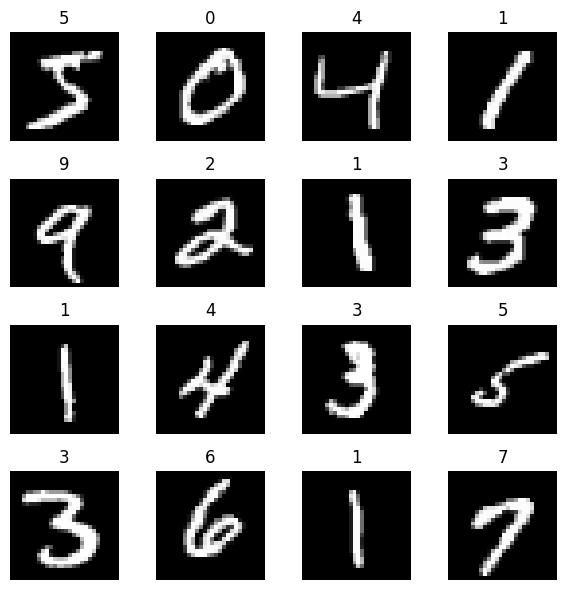

In [71]:
from matplotlib import pyplot as plt

def plot_grid(x, y, grid_size):
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    
    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            
            axes[i, j].imshow(x[idx], cmap='gray')
            axes[i, j].set_title(str(y[idx]))
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()
plot_grid(x_train, y_train, grid_size=4)


### Prepare the dataset

We will prepare the dataset by normalizing the pixel values and converting the labels to one-hot encoding.
> Images have pixel values ranging from 0 to 255. Normalizing these values to a range of 0 to 1 helps improve the convergence of the neural network during training.

In [72]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

We convert each image from a 28x28 array to a 784-dimensional vector (28 * 28 = 784) to feed into the feedforward neural network.
> numpy will calculate the size automatically with -1

In [73]:
X_train = x_train.reshape((x_train.shape[0], -1))
X_test = x_test.reshape((x_test.shape[0], -1))

Finally, we adjust our labels from 0-9 to one-hot encoded vectors.
> We can use sklearn's LabelBinarizer or Keras's to_categorical for this task.

In [74]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

print(f'New structure for labels: {y_train[0]}')

New structure for labels: [0 0 0 0 0 1 0 0 0 0]


This way the output layer of our neural network can have 10 neurons, each representing a class, and the target output for each image will be a vector with a 1 in the position corresponding to the correct class and 0s elsewhere.

### Design the neural network architecture

- Input Layer: 784 neurons (one for each pixel in the flattened image)
- Output Layer: 10 neurons (one for each class in the MNIST dataset)
- Activation Function: We have a multi-class classification problem, so we will use the softmax activation function in the output layer to get probabilities for each class.

In [75]:
from keras.models import Sequential
from keras.layers import Input, Dense

# We build the feedforward neural network
model = Sequential()
model.add(Input(shape=(784,)))  # Input layer
model.add(Dense(512, activation='relu'))  # Hidden layer with 512 neurons
model.add(Dense(256, activation='relu'))   # Hidden layer with 256 neurons
model.add(Dense(10, activation='softmax'))  # Output layer with 10 neurons for 10 classes

> We will use Stochastic Gradient Descent (SGD) as the optimizer, categorical crossentropy as the loss function (suitable for multi-class classification), and accuracy as the evaluation metric.

In [76]:
from keras.optimizers import SGD

opt = SGD(learning_rate=0.01)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
H = model.fit(X_train, y_train, epochs=20, batch_size=150, validation_data=(X_test, y_test)) 

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7328 - loss: 1.1932 - val_accuracy: 0.8681 - val_loss: 0.5710
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8791 - loss: 0.4795 - val_accuracy: 0.9006 - val_loss: 0.3872
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8989 - loss: 0.3734 - val_accuracy: 0.9100 - val_loss: 0.3299
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9087 - loss: 0.3283 - val_accuracy: 0.9175 - val_loss: 0.2980
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9154 - loss: 0.3005 - val_accuracy: 0.9232 - val_loss: 0.2772
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9199 - loss: 0.2801 - val_accuracy: 0.9253 - val_loss: 0.2612
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9250 - loss: 0.2637 - val_accuracy: 0.9298 - val_loss: 0.2486
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9284 - loss: 0.2503 - val_accuracy: 0.

After training the model, we will evaluate its performance on the test dataset and analyze the results.

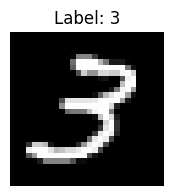

In [77]:
import numpy as np

# We plot a random image from the test set along with its label
index = np.random.randint(0, X_test.shape[0])
plt.figure(figsize=(2, 2))
plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
plt.title(f'Label: {y_test[index].argmax()}')
plt.axis('off')
plt.show()

And we validate the model by predicting a random image from the test set and displaying it along with its predicted label.

In [78]:
prediction = model.predict(X_test[index].reshape(1, -1))
predicted_class = np.argmax(prediction)
print(f'Actual: {np.argmax(y_test[index])}')
print(f'Predicted: {predicted_class}')
print(f'Prediction confidence: {prediction.max() * 100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Actual: 3
Predicted: 3
Prediction confidence: 99.58%


The results are really good with some digits being more difficult to classify due to their similar shapes.

In [79]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test, batch_size=150)
training_report = classification_report(y_test.argmax(axis=1), predictions.argmax(axis=1), target_names=class_names)
print(training_report)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.95      0.95      0.95      1032
           3       0.93      0.95      0.94      1010
           4       0.96      0.95      0.96       982
           5       0.96      0.93      0.94       892
           6       0.95      0.97      0.96       958
           7       0.96      0.94      0.95      1028
           8       0.93      0.94      0.94       974
           9       0.95      0.94      0.94      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



Digits like '3' and '5' or '8' and '9' can be easily confused due to their similar structures, especially if the handwriting is not clear.

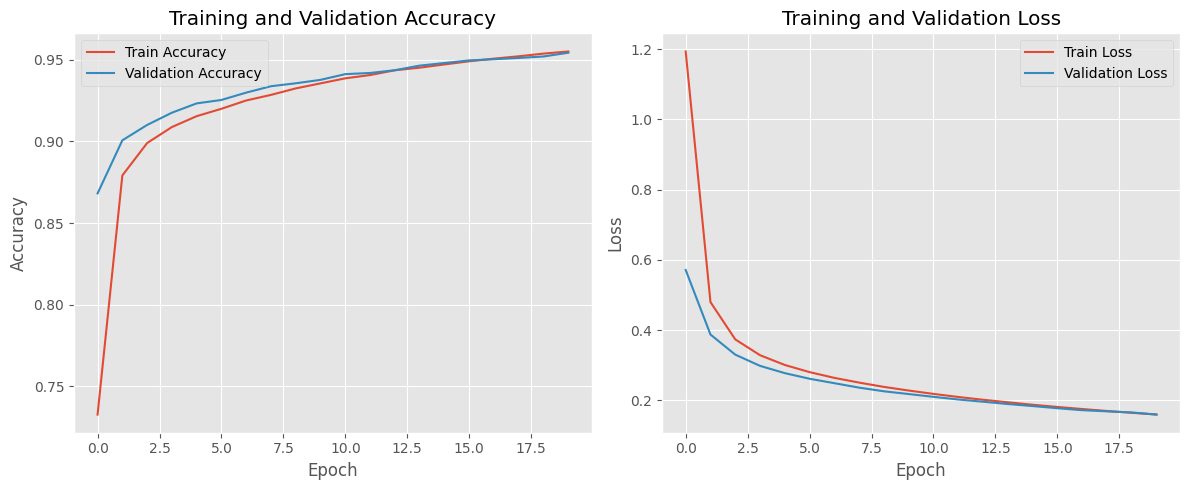

In [80]:
def print_training_metrics(H):
    """Plot training & validation accuracy and loss values"""
    plt.style.use("ggplot")
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(H.history['accuracy'], label='Train Accuracy')
    plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(H.history['loss'], label='Train Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print_training_metrics(H)

The results are good with an overall accuracy above 95%.